In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
import matplotlib.pyplot as plt

def plot_curves(history, model_name, phase):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{model_name} – {phase} Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{model_name} – {phase} Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{model_name}_{phase}_curves.png', dpi=300)
    plt.show()

# For initial transfer learning
for model in models_to_test:
    plot_curves(training_histories[model], model, 'Transfer_Learning')

# For fine-tuning
for model in models_to_test:
    plot_curves(fine_tune_histories[model], model, 'Fine_Tune')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1654s 10us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10


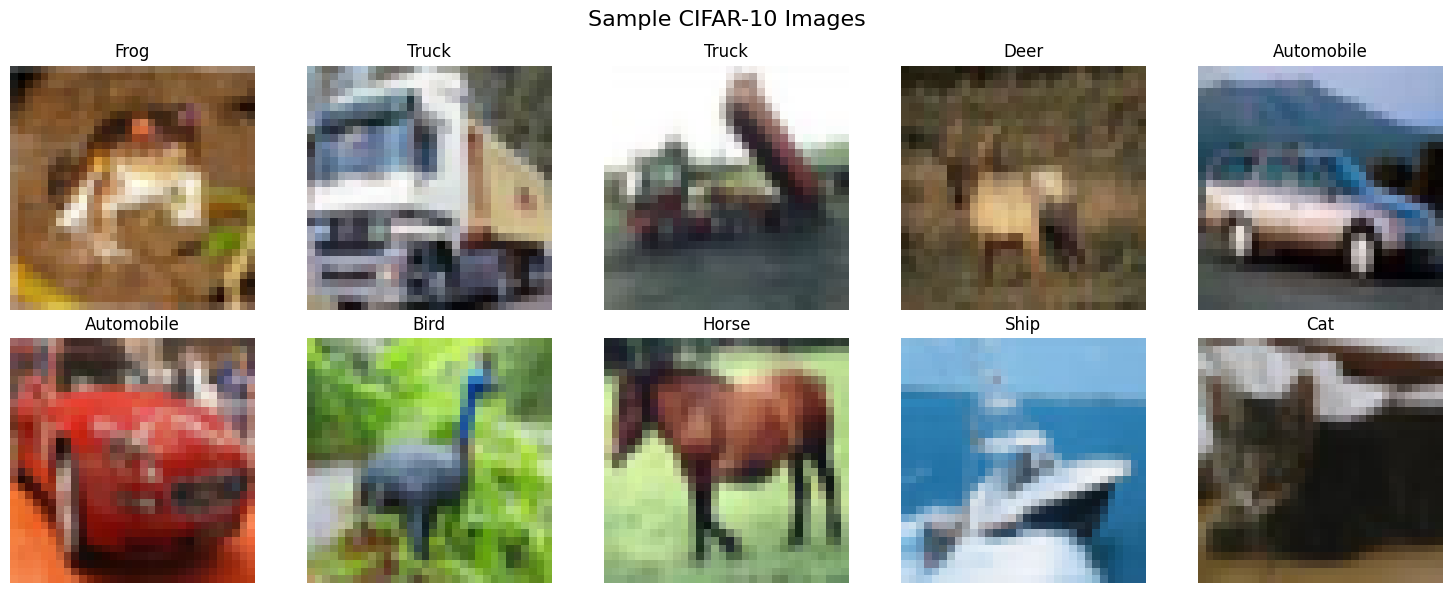

In [14]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Dataset dimensions
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Display sample images
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(f'{class_names[y_train[i][0]]}')
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=16)
plt.tight_layout()
plt.savefig('sample_cifar10_images.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
def prepare_pretrained_model(model_name, input_shape=(32, 32, 3)):
    """
    Prepare a pretrained model for transfer learning.
    """
    if model_name == 'VGG16':
        return VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50':
        return ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'MobileNetV2':
        return MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Model {model_name} not supported")

def build_transfer_learning_model(base_model, num_classes=10):
    """
    Build a transfer learning model with a pretrained base.
    """
    # Freeze the base model layers
    base_model.trainable = False

    # Build the model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Define model configurations
models_to_test = ['VGG16', 'ResNet50', 'MobileNetV2']
pretrained_models = {}
training_histories = {}
fine_tune_histories = {}

print("\n" + "="*60)
print("BUILDING PRETRAINED MODELS")
print("="*60)

for model_name in models_to_test:
    print(f"\nBuilding {model_name}...")

    # Prepare base model
    base_model = prepare_pretrained_model(model_name, input_shape=(32, 32, 3))
    pretrained_models[model_name] = base_model

    # Build full model
    model = build_transfer_learning_model(base_model)

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Store model
    pretrained_models[f"{model_name}_full"] = model

    # Print summary (only for first few layers to keep output clean)
    print(f"Total layers: {len(model.layers)}")
    print(f"Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])}")
    print(f"Non-trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])}")


BUILDING PRETRAINED MODELS

Building VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers: 7
Trainable parameters: 165514
Non-trainable parameters: 14714688

Building ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layers: 7
Trainable parameters: 558730
Non-trainable parameters: 23587712

Building MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers: 7
Trainable parameters: 362122
Non-trainable parameters: 2257984


In [16]:
def train_model(model, model_name, x_train, y_train_cat, epochs=15):
    """
 Train a model and return training history.
    """
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        f'{model_name}_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    )

    # Train the model
    history = model.fit(
        x_train, y_train_cat,
        batch_size=32,
        epochs=epochs,
        validation_split=0.2,
        callbacks=[early_stopping, checkpoint],
        verbose=1
    )

    return history

print("\n" + "="*60)
print("TRAINING MODELS (Transfer Learning)")
print("="*60)

for model_name in models_to_test:
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print('='*50)

    model = pretrained_models[f"{model_name}_full"]
    history = train_model(model, model_name, x_train, y_train_cat, epochs=15)
    training_histories[model_name] = history



TRAINING MODELS (Transfer Learning)

Training VGG16...
Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3591 - loss: 1.7897

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4296 - loss: 1.6086 - val_accuracy: 0.5379 - val_loss: 1.3062
Epoch 2/15
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5066 - loss: 1.4066

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5140 - loss: 1.3922 - val_accuracy: 0.5563 - val_loss: 1.2570
Epoch 3/15
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5391 - loss: 1.3261

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5377 - loss: 1.3264 - val_accuracy: 0.5741 - val_loss: 1.2136
Epoch 4/15
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5502 - loss: 1.2907

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.5511 - loss: 1.2897 - val_accuracy: 0.5781 - val_loss: 1.2011
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5637 - loss: 1.2513

...

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3423 - loss: 1.8050 - val_accuracy: 0.3547 - val_loss: 1.7833
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3446 - loss: 1.7925

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3456 - loss: 1.7924 - val_accuracy: 0.3556 - val_loss: 1.7787
Epoch 8/15
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3559 - loss: 1.7790

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3515 - loss: 1.7795 - val_accuracy: 0.3575 - val_loss: 1.7783
Epoch 9/15
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3559 - loss: 1.7781

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3555 - loss: 1.7759 - val_accuracy: 0.3600 - val_loss: 1.7770
Epoch 10/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3582 - loss: 1.7651 - val_accuracy: 0.3589 - val_loss: 1.7751
Epoch 11/15
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3599 - loss: 1.7604

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3605 - loss: 1.7578 - val_accuracy: 0.3605 - val_loss: 1.7734
Epoch 12/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3619 - loss: 1.7536 - val_accuracy: 0.3582 - val_loss: 1.7724
Epoch 13/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3624 - loss: 1.7463 - val_accuracy: 0.3589 - val_loss: 1.7717
Epoch 14/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3652 - loss: 1.7441 - val_accuracy: 0.3586 - val_loss: 1.7745
Epoch 15/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3683 - loss: 1.7359 - val_accuracy: 0.3600 - val_loss: 1.7746


In [17]:
def fine_tune_model(model, base_model, model_name, x_train, y_train_cat, epochs=10):
    """
    Fine-tune the model by unfreezing the last few layers.
    """
    print(f"\n{'='*50}")
    print(f"Fine-tuning {model_name}...")
    print('='*50)

    # Unfreeze the last convolution block
    base_model.trainable = True

    # Freeze all layers except the last block
    if model_name == 'VGG16':
        # Unfreeze last 4 layers (block5)
        for layer in base_model.layers:
            if 'block5' in layer.name:
                layer.trainable = True
            else:
                layer.trainable = False
    elif model_name == 'ResNet50':
        # Unfreeze last 50 layers
        for i, layer in enumerate(base_model.layers):
            if i < len(base_model.layers) - 50:
                layer.trainable = False
            else:
                layer.trainable = True
    elif model_name == 'MobileNetV2':
        # Unfreeze last 30 layers
        for i, layer in enumerate(base_model.layers):
            if i < len(base_model.layers) - 30:
                layer.trainable = False
            else:
                layer.trainable = True

    # Recompile with lower learning rate
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Train for additional epochs
    history = model.fit(
        x_train, y_train_cat,
        batch_size=32,
        epochs=epochs,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    return history

for model_name in models_to_test:
    model = pretrained_models[f"{model_name}_full"]
    base_model = pretrained_models[model_name]

    fine_tune_history = fine_tune_model(
        model, base_model, model_name,
        x_train, y_train_cat, epochs=8
    )
    fine_tune_histories[model_name] = fine_tune_history



Fine-tuning VGG16...
Epoch 1/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.5938 - loss: 1.2003 - val_accuracy: 0.6721 - val_loss: 0.9542
Epoch 2/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6882 - loss: 0.9204 - val_accuracy: 0.6900 - val_loss: 0.9067
Epoch 3/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7324 - loss: 0.7810 - val_accuracy: 0.7146 - val_loss: 0.8415
Epoch 4/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7736 - loss: 0.6628 - val_accuracy: 0.7221 - val_loss: 0.8535
Epoch 5/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8073 - loss: 0.5641 - val_accuracy: 0.7258 - val_loss: 0.8793
Epoch 6/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8334 - loss: 0.4827 - val_accuracy: 0.7269 - val_loss: 0.9909
Epoch 7/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8621 - loss: 0.4044 - val_accuracy: 0.7203 - val_loss: 1.0625
Epoch 8/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accu

In [18]:
def evaluate_model(model, model_name, x_test, y_test_cat, y_test):
    """
    Evaluate model performance with various metrics.
    """
    # Import metrics locally to ensure they're available
    from sklearn.metrics import (
        confusion_matrix,
        classification_report,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score
    )

    print(f"\n{'='*50}")
    print(f"Evaluating {model_name}...")
    print('='*50)

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

    # Get predictions
    y_pred_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Flatten y_test for metrics
    y_true = y_test.flatten()

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Print metrics
    print(f"\nPerformance Metrics:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Return metrics
    return {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'predictions': y_pred
    }

print("✓ Evaluation function defined successfully!")

✓ Evaluation function defined successfully!



STARTING MODEL EVALUATION

Evaluating VGG16...

Performance Metrics:
Test Loss: 0.8485
Test Accuracy: 0.7107
Accuracy: 0.7107
Precision: 0.7087
Recall: 0.7107
F1-Score: 0.7065

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.80      0.78      0.79      1000
  Automobile       0.75      0.87      0.80      1000
        Bird       0.67      0.65      0.66      1000
         Cat       0.56      0.47      0.51      1000
        Deer       0.70      0.59      0.64      1000
         Dog       0.65      0.54      0.59      1000
        Frog       0.68      0.80      0.74      1000
       Horse       0.68      0.83      0.75      1000
        Ship       0.86      0.80      0.83      1000
       Truck       0.74      0.77      0.76      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



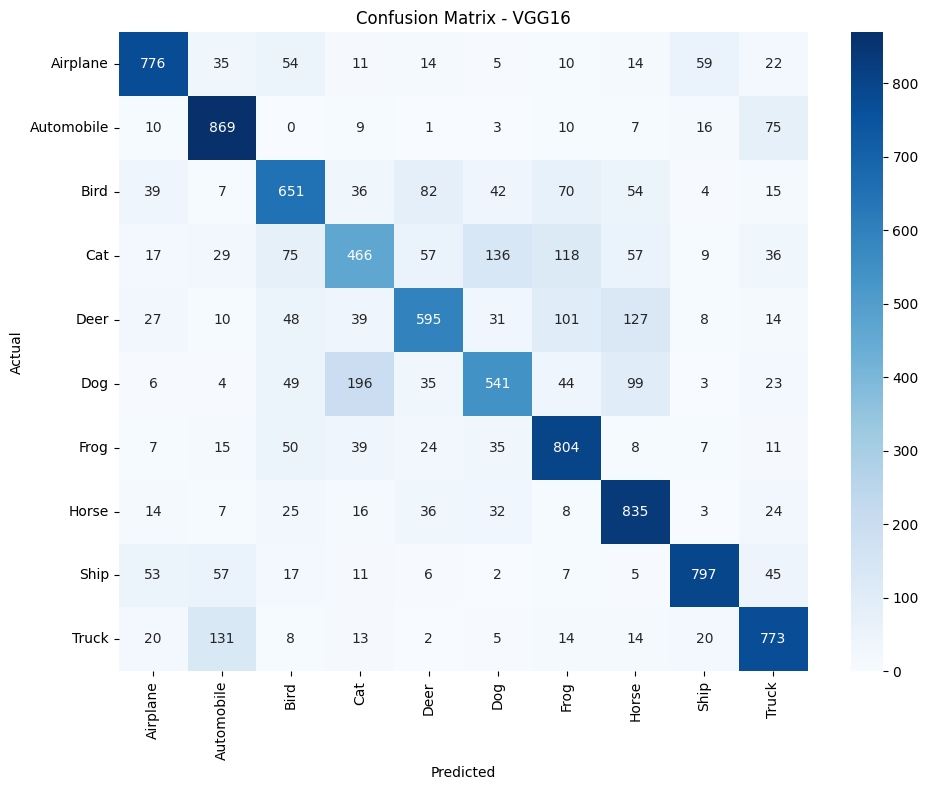


Evaluating ResNet50...

Performance Metrics:
Test Loss: 2.3001
Test Accuracy: 0.1101
Accuracy: 0.1101
Precision: 0.1643
Recall: 0.1101
F1-Score: 0.0411

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.44      0.03      0.06      1000
  Automobile       0.54      0.04      0.08      1000
        Bird       0.00      0.00      0.00      1000
         Cat       0.11      0.98      0.19      1000
        Deer       0.00      0.00      0.00      1000
         Dog       0.00      0.00      0.00      1000
        Frog       0.00      0.00      0.00      1000
       Horse       0.01      0.01      0.01      1000
        Ship       0.32      0.03      0.06      1000
       Truck       0.22      0.00      0.00      1000

    accuracy                           0.11     10000
   macro avg       0.16      0.11      0.04     10000
weighted avg       0.16      0.11      0.04     10000



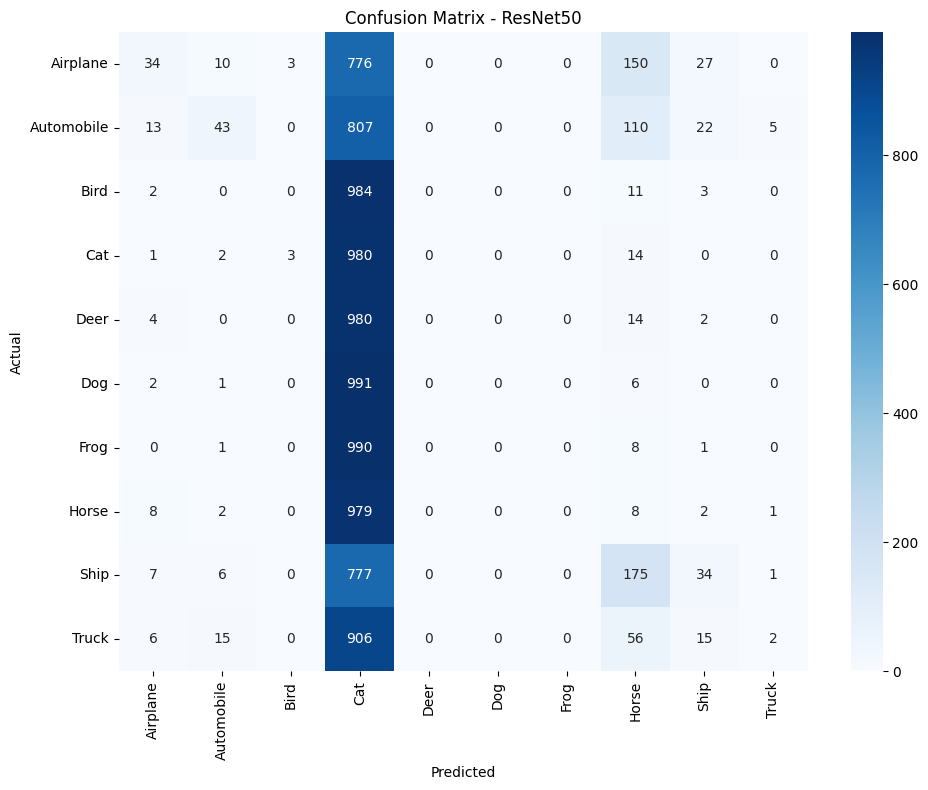


Evaluating MobileNetV2...

Performance Metrics:
Test Loss: 1.3709
Test Accuracy: 0.5516
Accuracy: 0.5516
Precision: 0.5532
Recall: 0.5516
F1-Score: 0.5478

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.60      0.55      0.57      1000
  Automobile       0.64      0.60      0.62      1000
        Bird       0.49      0.33      0.39      1000
         Cat       0.44      0.35      0.39      1000
        Deer       0.50      0.54      0.52      1000
         Dog       0.43      0.57      0.49      1000
        Frog       0.65      0.64      0.65      1000
       Horse       0.59      0.56      0.58      1000
        Ship       0.54      0.70      0.61      1000
       Truck       0.64      0.67      0.66      1000

    accuracy                           0.55     10000
   macro avg       0.55      0.55      0.55     10000
weighted avg       0.55      0.55      0.55     10000



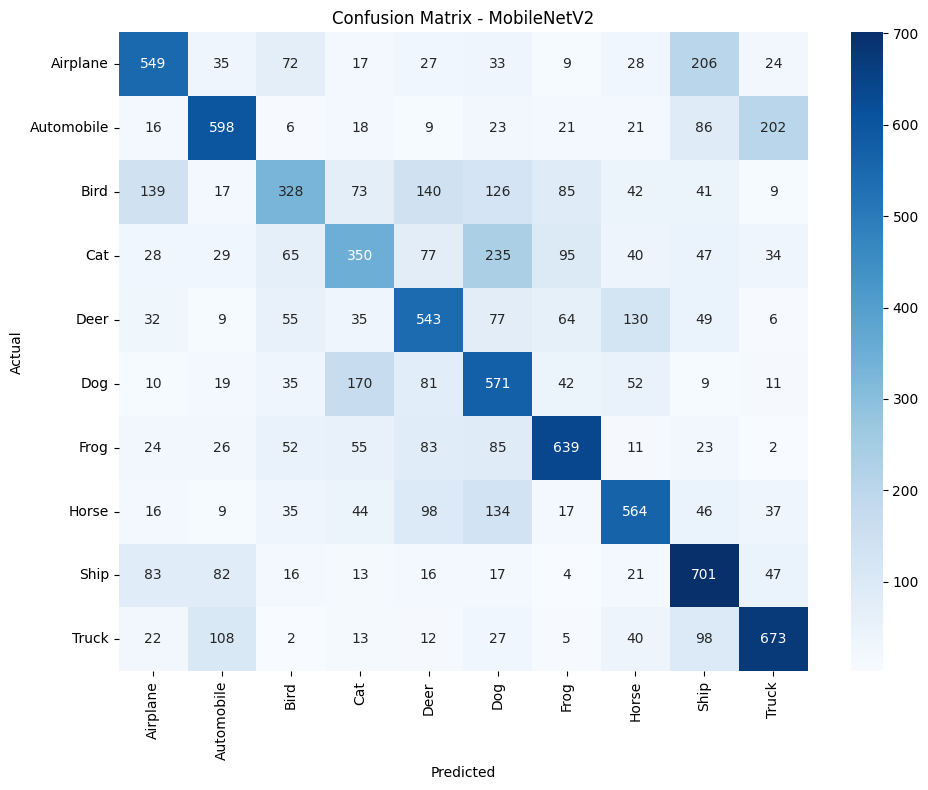


✓ EVALUATION COMPLETED FOR ALL MODELS


In [19]:
# Evaluate each model
evaluation_results = {}

print("\n" + "="*60)
print("STARTING MODEL EVALUATION")
print("="*60)

for model_name in models_to_test:
    model = pretrained_models[f"{model_name}_full"]
    results = evaluate_model(model, model_name, x_test, y_test_cat, y_test)
    evaluation_results[model_name] = results

print("\n" + "="*60)
print("✓ EVALUATION COMPLETED FOR ALL MODELS")
print("="*60)

In [20]:
print("\n" + "="*80)
print("PERFORMANCE METRICS SUMMARY")
print("="*80)
print(f"{'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Test Acc':<12}")
print("-"*80)

for model_name in models_to_test:
    res = evaluation_results[model_name]
    print(f"{model_name:<15} {res['accuracy']:.4f}     {res['precision']:.4f}     {res['recall']:.4f}     {res['f1']:.4f}     {res['test_accuracy']:.4f}")
print("="*80)



PERFORMANCE METRICS SUMMARY
Model           Accuracy     Precision    Recall       F1-Score     Test Acc    
--------------------------------------------------------------------------------
VGG16           0.7107     0.7087     0.7107     0.7065     0.7107
ResNet50        0.1101     0.1643     0.1101     0.0411     0.1101
MobileNetV2     0.5516     0.5532     0.5516     0.5478     0.5516


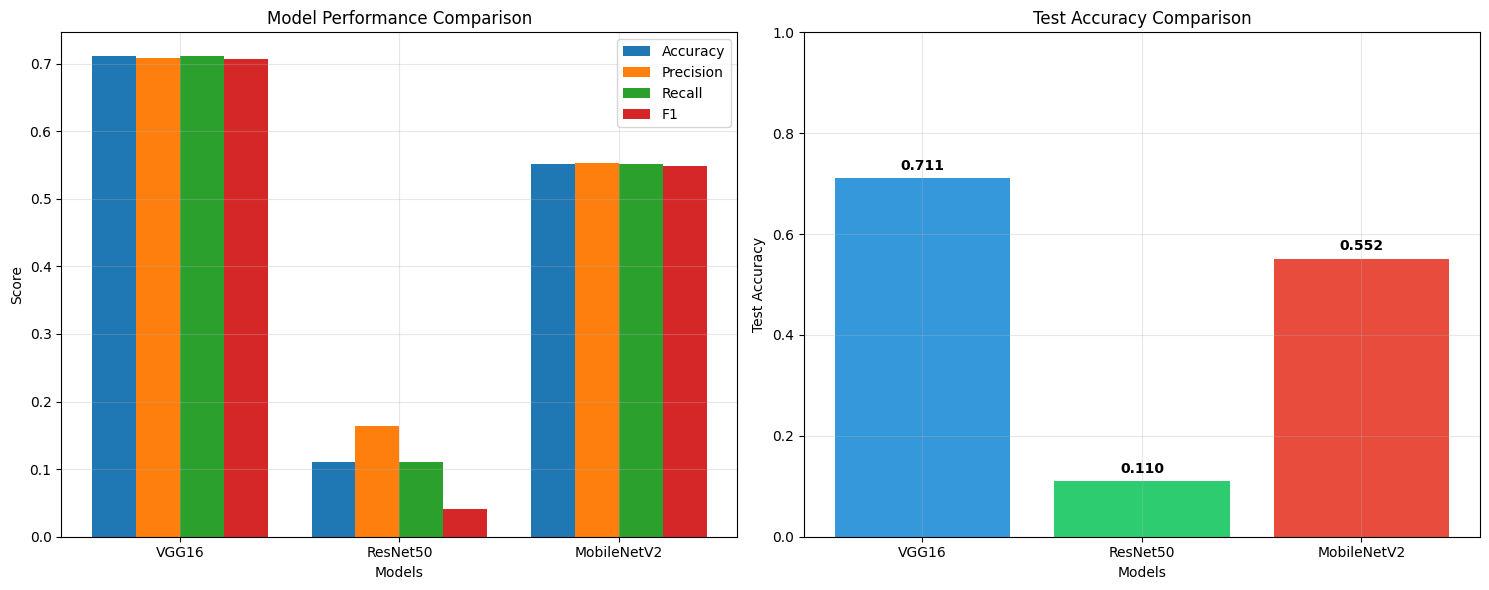

✓ Model comparison plot saved as 'model_comparison.png'


In [21]:
def plot_model_comparison(evaluation_results):
    """
    Create comparison plots for different models.
    """
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    models = list(evaluation_results.keys())

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Bar plot for metrics
    x = np.arange(len(models))
    width = 0.2

    for i, metric in enumerate(metrics):
        values = [evaluation_results[model][metric] for model in models]
        axes[0].bar(x + i*width, values, width, label=metric.capitalize())

    axes[0].set_xlabel('Models')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Model Performance Comparison')
    axes[0].set_xticks(x + width * 1.5)
    axes[0].set_xticklabels(models)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Test accuracy comparison
    accuracies = [evaluation_results[model]['test_accuracy'] for model in models]
    bars = axes[1].bar(models, accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
    axes[1].set_xlabel('Models')
    axes[1].set_ylabel('Test Accuracy')
    axes[1].set_title('Test Accuracy Comparison')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)

    # Add values on top of bars
    for i, v in enumerate(accuracies):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_model_comparison(evaluation_results)
print("✓ Model comparison plot saved as 'model_comparison.png'")


MISCLASSIFIED IMAGES

VGG16 - Misclassified: 2893 out of 10000 (28.93%)


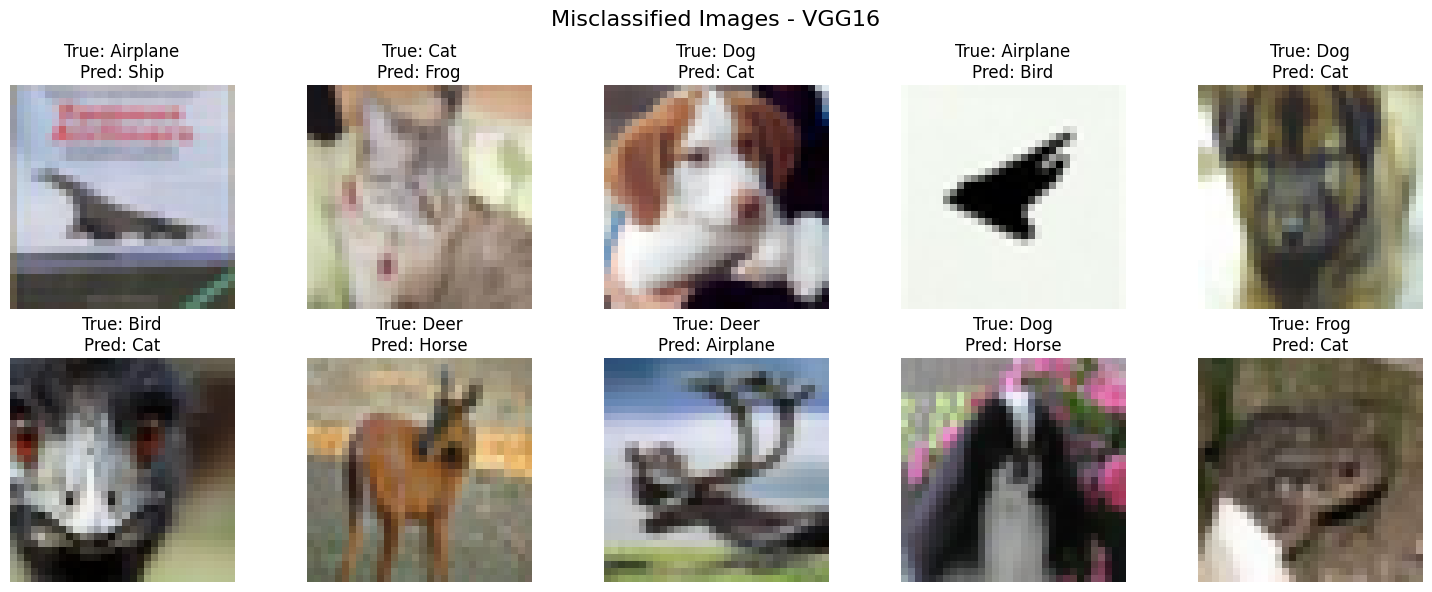


ResNet50 - Misclassified: 8899 out of 10000 (88.99%)


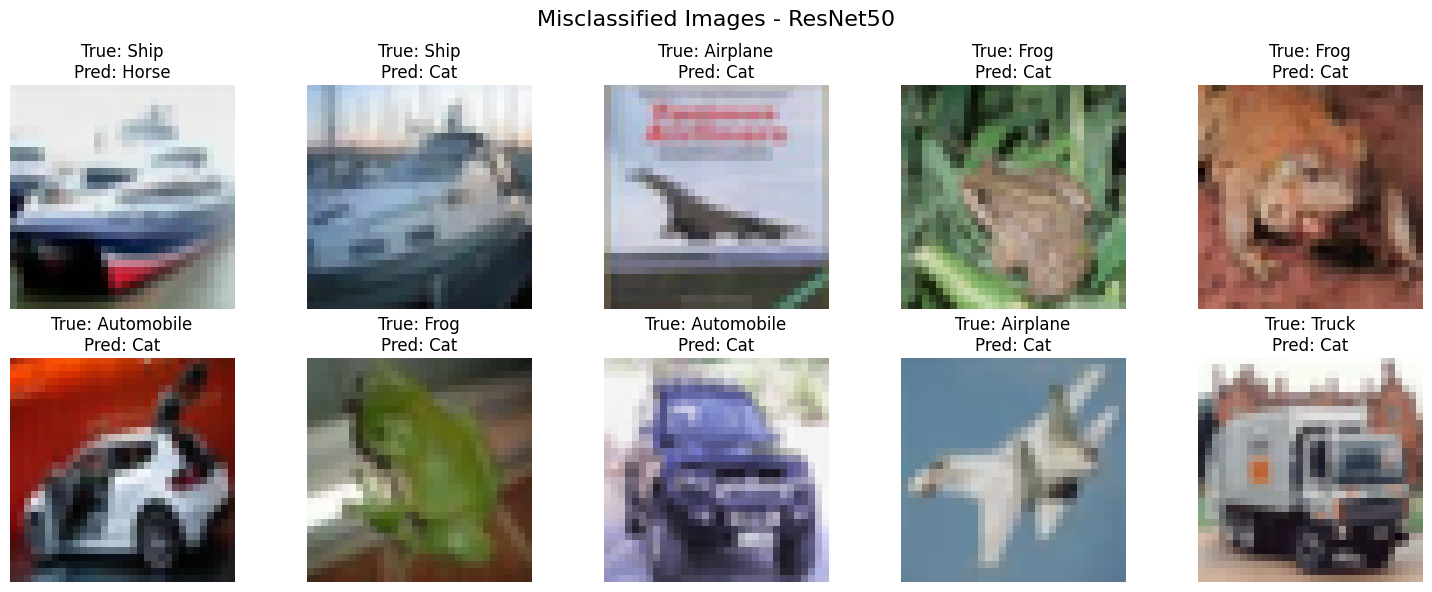


MobileNetV2 - Misclassified: 4484 out of 10000 (44.84%)


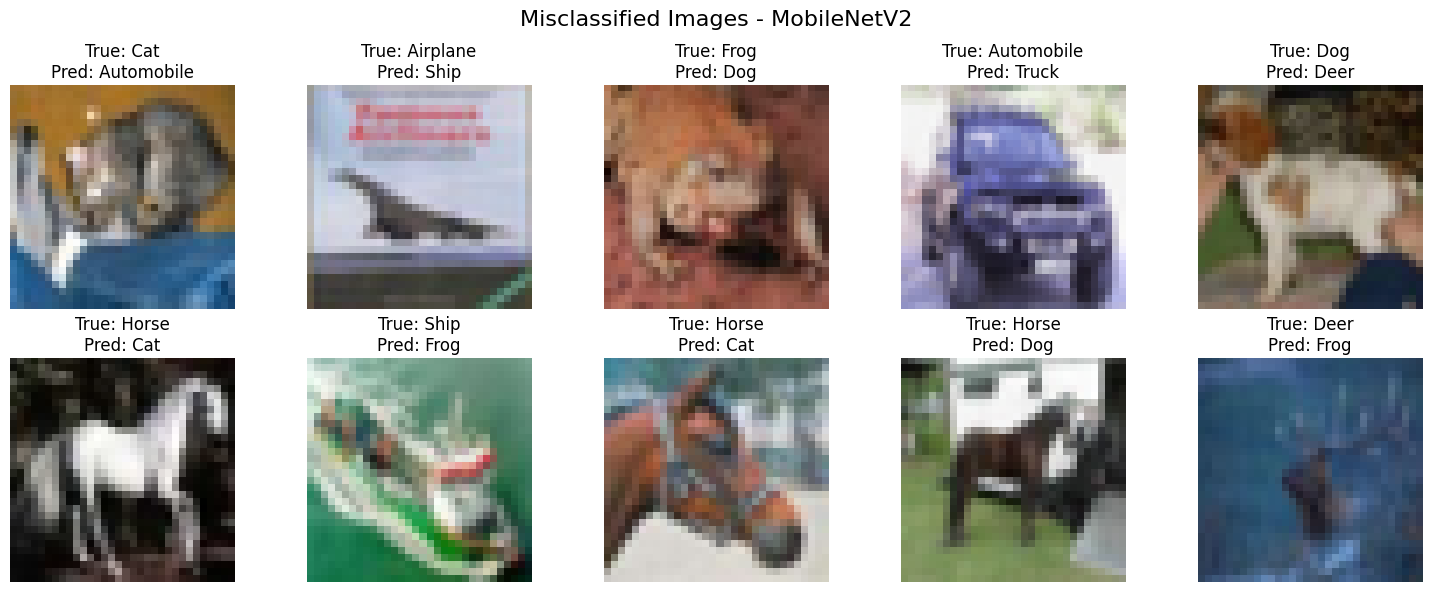

In [22]:
def plot_misclassified_images(model, model_name, x_test, y_test, class_names):
    """
    Display misclassified images.
    """
    # Get predictions
    y_pred_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = y_test.flatten()

    # Find misclassified indices
    misclassified_idx = np.where(y_pred != y_true)[0]

    print(f"\n{model_name} - Misclassified: {len(misclassified_idx)} out of {len(y_true)} ({len(misclassified_idx)/len(y_true)*100:.2f}%)")

    # Display first 10 misclassified images
    if len(misclassified_idx) > 0:
        plt.figure(figsize=(15, 6))
        num_to_show = min(10, len(misclassified_idx))
        for i, idx in enumerate(misclassified_idx[:num_to_show]):
            plt.subplot(2, 5, i+1)
            plt.imshow(x_test[idx])
            plt.title(f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}')
            plt.axis('off')
        plt.suptitle(f'Misclassified Images - {model_name}', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'misclassified_{model_name}.png', dpi=300, bbox_inches='tight')
        plt.show()

print("\n" + "="*60)
print("MISCLASSIFIED IMAGES")
print("="*60)

for model_name in models_to_test:
    model = pretrained_models[f"{model_name}_full"]
    plot_misclassified_images(model, model_name, x_test, y_test, class_names)

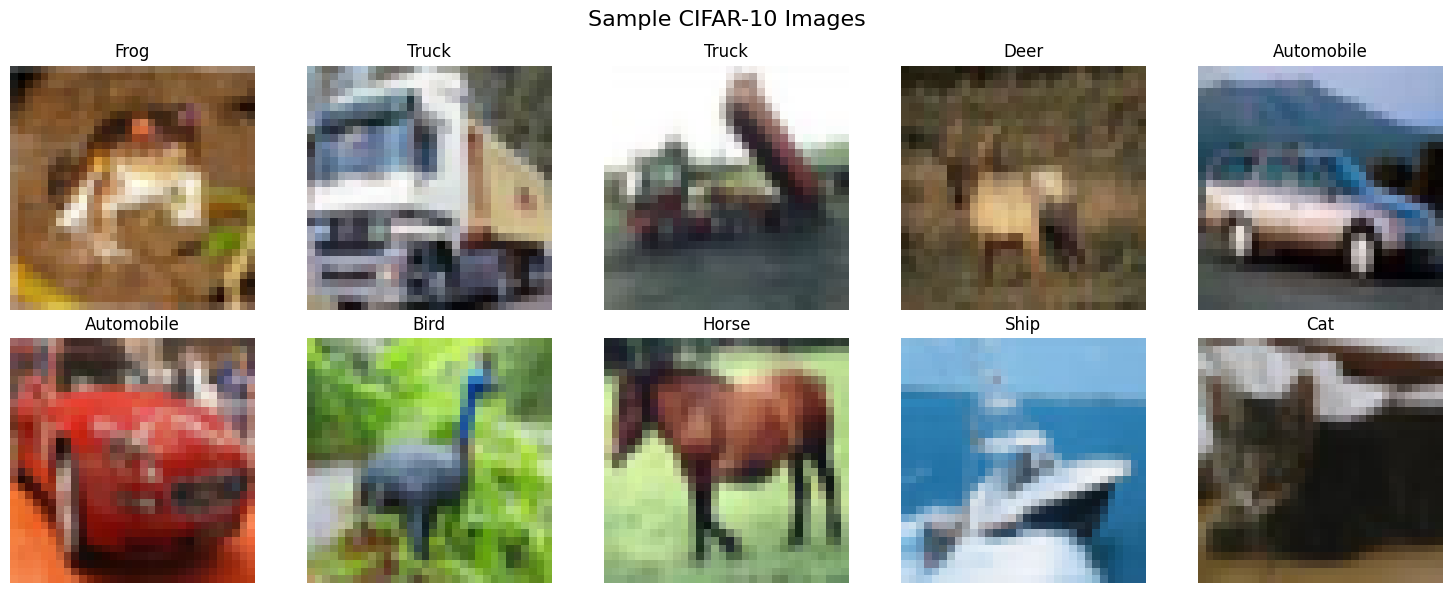

✓ Sample images saved as 'sample_cifar10_images.png'


In [23]:
# Display sample images
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(f'{class_names[y_train[i][0]]}')
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=16)
plt.tight_layout()
plt.savefig('sample_cifar10_images.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Sample images saved as 'sample_cifar10_images.png'")

In [24]:
print("\n" + "="*80)
print("EXPERIMENT 4: DEEP CNN ARCHITECTURES AND TRANSFER LEARNING")
print("="*80)
print("\nFINAL RESULTS SUMMARY:")
print("-"*80)

best_model = max(evaluation_results, key=lambda x: evaluation_results[x]['test_accuracy'])
best_accuracy = evaluation_results[best_model]['test_accuracy']

for model_name in models_to_test:
    res = evaluation_results[model_name]
    print(f"\n{model_name}:")
    print(f"  ✓ Test Accuracy: {res['test_accuracy']:.4f} ({res['test_accuracy']*100:.2f}%)")
    print(f"  ✓ Precision: {res['precision']:.4f}")
    print(f"  ✓ Recall: {res['recall']:.4f}")
    print(f"  ✓ F1-Score: {res['f1']:.4f}")

print("\n" + "="*80)
print(f"🏆 BEST MODEL: {best_model} with Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("="*80)

print("\n📊 All plots have been saved as PNG files:")
print("  - sample_cifar10_images.png")
print("  - confusion_matrix_*.png (for each model)")
print("  - misclassified_*.png (for each model)")
print("  - model_comparison.png")

print("\n✅ Experiment Completed Successfully!")


EXPERIMENT 4: DEEP CNN ARCHITECTURES AND TRANSFER LEARNING

FINAL RESULTS SUMMARY:
--------------------------------------------------------------------------------

VGG16:
  ✓ Test Accuracy: 0.7107 (71.07%)
  ✓ Precision: 0.7087
  ✓ Recall: 0.7107
  ✓ F1-Score: 0.7065

ResNet50:
  ✓ Test Accuracy: 0.1101 (11.01%)
  ✓ Precision: 0.1643
  ✓ Recall: 0.1101
  ✓ F1-Score: 0.0411

MobileNetV2:
  ✓ Test Accuracy: 0.5516 (55.16%)
  ✓ Precision: 0.5532
  ✓ Recall: 0.5516
  ✓ F1-Score: 0.5478

🏆 BEST MODEL: VGG16 with Test Accuracy: 0.7107 (71.07%)

📊 All plots have been saved as PNG files:
  - sample_cifar10_images.png
  - confusion_matrix_*.png (for each model)
  - misclassified_*.png (for each model)
  - model_comparison.png

✅ Experiment Completed Successfully!
